# Kalshi Markets Inspection

This notebook loads `raw_markets` from the Kalshi SQLite database and inspects a first-version market filter:

- `market_type == binary`
- `volume_num >= 20000`

Structured / MVE fields are still inspected, but they are not excluded automatically in this first version.

Figures are saved into `artefacts/kalshi_plots`.


In [1]:
from __future__ import annotations

import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", None)


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "kalshi_export").exists() and (candidate / "db").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")


REPO_ROOT = find_repo_root(Path.cwd())
KALSHI_EXPORT_ROOT = REPO_ROOT / "kalshi_export"
DB_PATH = REPO_ROOT / "db" / "kalshi_probability_dataset.sqlite"
PLOTS_DIR = REPO_ROOT / "artefacts" / "kalshi_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for path in (REPO_ROOT, KALSHI_EXPORT_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"REPO_ROOT={REPO_ROOT}")
print(f"KALSHI_EXPORT_ROOT={KALSHI_EXPORT_ROOT}")
print(f"DB_PATH={DB_PATH}")
print(f"PLOTS_DIR={PLOTS_DIR}")


def save_plot(name: str) -> Path:
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(path)
    return path


REPO_ROOT=/Users/sneddy/research/polymarket_research
KALSHI_EXPORT_ROOT=/Users/sneddy/research/polymarket_research/kalshi_export
DB_PATH=/Users/sneddy/research/polymarket_research/db/kalshi_probability_dataset.sqlite
PLOTS_DIR=/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots


In [3]:
with sqlite3.connect(DB_PATH) as conn:
    raw_markets = pd.read_sql_query("SELECT * FROM raw_markets", conn)

print(f"raw_markets={raw_markets.shape}")
raw_markets.head(3)


raw_markets=(60161, 63)


,market_id,source,venue_market_id,event_id,venue_event_id,series_ticker,ticker,event_ticker,title,question,...,description,end_date,final_outcome,final_yes_probability,is_binary,is_resolved,is_active,is_closed,data_source_kind,indexed_at_utc
0,kalshi:AUCTIONPRICETREY-26-4000000,kalshi,AUCTIONPRICETREY-26-4000000,kalshi:event:AUCTIONPRICETREY-26,AUCTIONPRICETREY-26,AUCTIONPRICETREY,AUCTIONPRICETREY-26-4000000,AUCTIONPRICETREY-26,What will Trey the Triceratops (Sub-Adult Triceratops Skeleton) go for at auction?,What will Trey the Triceratops (Sub-Adult Triceratops Skeleton) go for at auction?,...,"If Trey the Triceratops (Sub-Adult Triceratops Skeleton) sells at auction for at least $4000000 before Apr 1, 2026, then the market resolves to Yes.",2026-04-08T14:00:00Z,yes,1.0,1,1,0,1,markets_live_index,2026-04-17T10:52:32Z
1,kalshi:AUCTIONPRICETREY-26-4500000,kalshi,AUCTIONPRICETREY-26-4500000,kalshi:event:AUCTIONPRICETREY-26,AUCTIONPRICETREY-26,AUCTIONPRICETREY,AUCTIONPRICETREY-26-4500000,AUCTIONPRICETREY-26,What will Trey the Triceratops (Sub-Adult Triceratops Skeleton) go for at auction?,What will Trey the Triceratops (Sub-Adult Triceratops Skeleton) go for at auction?,...,"If Trey the Triceratops (Sub-Adult Triceratops Skeleton) sells at auction for at least $4500000 before Apr 1, 2026, then the market resolves to Yes.",2026-04-08T14:00:00Z,yes,1.0,1,1,0,1,markets_live_index,2026-04-17T10:52:32Z
2,kalshi:AUCTIONPRICETREY-26-5000000,kalshi,AUCTIONPRICETREY-26-5000000,kalshi:event:AUCTIONPRICETREY-26,AUCTIONPRICETREY-26,AUCTIONPRICETREY,AUCTIONPRICETREY-26-5000000,AUCTIONPRICETREY-26,What will Trey the Triceratops (Sub-Adult Triceratops Skeleton) go for at auction?,What will Trey the Triceratops (Sub-Adult Triceratops Skeleton) go for at auction?,...,"If Trey the Triceratops (Sub-Adult Triceratops Skeleton) sells at auction for at least $5000000 before Apr 1, 2026, then the market resolves to Yes.",2026-04-08T14:00:00Z,yes,1.0,1,1,0,1,markets_live_index,2026-04-17T10:52:32Z


In [4]:
summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "distinct_market_id",
            "distinct_event_ticker",
            "missing_series_ticker",
            "missing_volume_num",
        ],
        "value": [
            len(raw_markets),
            raw_markets["market_id"].nunique(),
            raw_markets["event_ticker"].dropna().nunique(),
            raw_markets["series_ticker"].fillna("").astype(str).str.strip().eq("").sum(),
            raw_markets["volume_num"].isna().sum(),
        ],
    }
)
summary


,metric,value
0,rows,60161
1,distinct_market_id,60161
2,distinct_event_ticker,8405
3,missing_series_ticker,0
4,missing_volume_num,0


In [5]:
data_source_counts = (
    raw_markets.assign(data_source_kind=raw_markets["data_source_kind"].fillna(""))
    .groupby("data_source_kind", dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)
data_source_counts


,data_source_kind,rows
0,markets_historical_index,51293
2,markets_live_index,8479
1,markets_live_and_historical_index,389


In [6]:
market_type_counts = (
    raw_markets.assign(market_type=raw_markets["market_type"].fillna(""))
    .groupby("market_type", dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)
market_type_counts.head(20)


,market_type,rows
0,binary,60161


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_markets_source_and_type.png


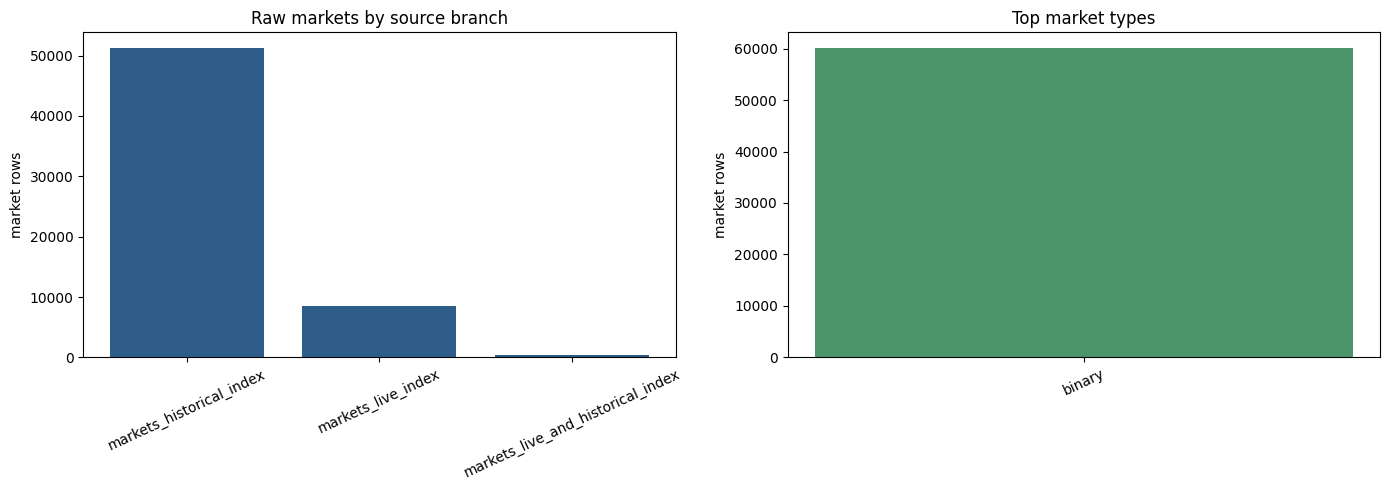

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(data_source_counts["data_source_kind"], data_source_counts["rows"], color="#2f5d8a")
axes[0].set_title("Raw markets by source branch")
axes[0].set_ylabel("market rows")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(market_type_counts["market_type"].head(10), market_type_counts["rows"].head(10), color="#4c956c")
axes[1].set_title("Top market types")
axes[1].set_ylabel("market rows")
axes[1].tick_params(axis="x", rotation=25)

save_plot("kalshi_raw_markets_source_and_type.png")
plt.show()


## Volume inspection

The first-version market filter uses `volume_num >= 20000`.

The visualizations below are meant to make that cutoff easy to justify in a benchmark paper.


In [8]:
volume = raw_markets["volume_num"].fillna(0)

volume_buckets = pd.DataFrame(
    {
        "bucket": [
            "0",
            "0-10k",
            "10k-20k",
            "20k-50k",
            "50k-100k",
            "100k-500k",
            ">500k",
        ],
        "rows": [
            volume.le(0).sum(),
            ((volume > 0) & (volume < 10000)).sum(),
            ((volume >= 10000) & (volume < 20000)).sum(),
            ((volume >= 20000) & (volume < 50000)).sum(),
            ((volume >= 50000) & (volume < 100000)).sum(),
            ((volume >= 100000) & (volume < 500000)).sum(),
            volume.ge(500000).sum(),
        ],
    }
)
volume_buckets["pct_rows"] = (100.0 * volume_buckets["rows"] / max(len(raw_markets), 1)).round(2)
volume_buckets


,bucket,rows,pct_rows
0,0,21522,35.77
1,0-10k,27236,45.27
2,10k-20k,3263,5.42
3,20k-50k,3130,5.20
4,50k-100k,1686,2.80
5,100k-500k,2328,3.87
6,>500k,996,1.66


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_markets_volume_hist.png


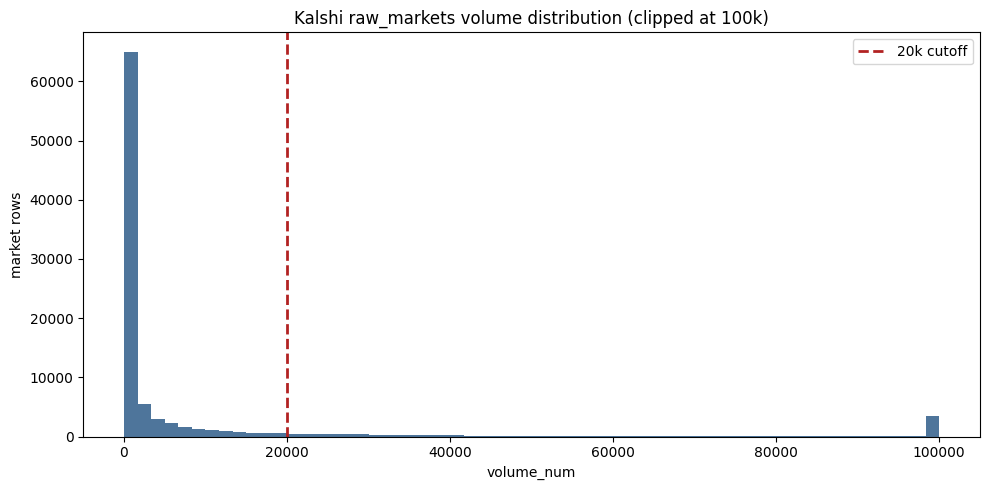

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(volume.clip(upper=100000), bins=60, color="#2f5d8a", alpha=0.85)
ax.axvline(20000, color="#b22222", linestyle="--", linewidth=2, label="20k cutoff")
ax.set_title("Kalshi raw_markets volume distribution (clipped at 100k)")
ax.set_xlabel("volume_num")
ax.set_ylabel("market rows")
ax.legend()
save_plot("kalshi_raw_markets_volume_hist.png")
plt.show()


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_markets_log_volume_hist.png


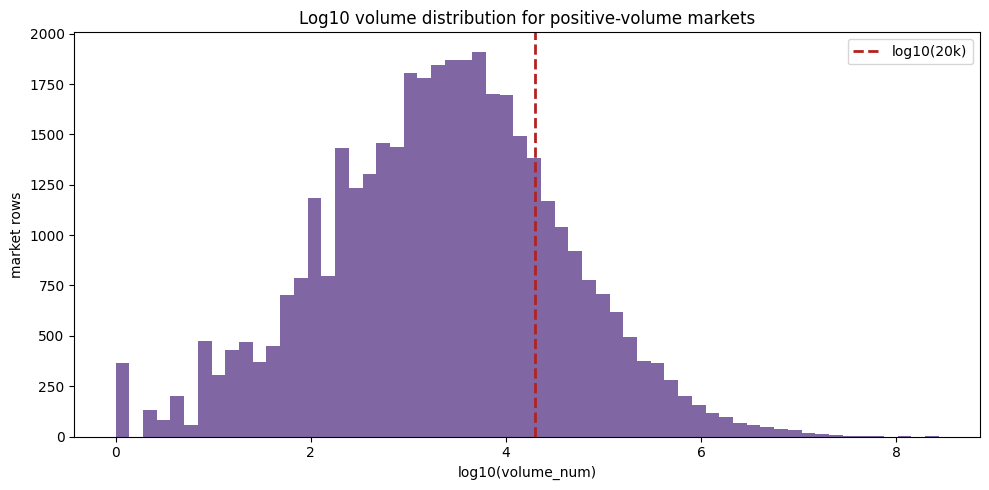

In [9]:
positive_volume = volume[volume > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(positive_volume.clip(lower=1)), bins=60, color="#6a4c93", alpha=0.85)
ax.axvline(np.log10(20000), color="#b22222", linestyle="--", linewidth=2, label="log10(20k)")
ax.set_title("Log10 volume distribution for positive-volume markets")
ax.set_xlabel("log10(volume_num)")
ax.set_ylabel("market rows")
ax.legend()
save_plot("kalshi_raw_markets_log_volume_hist.png")
plt.show()


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_markets_volume_buckets.png


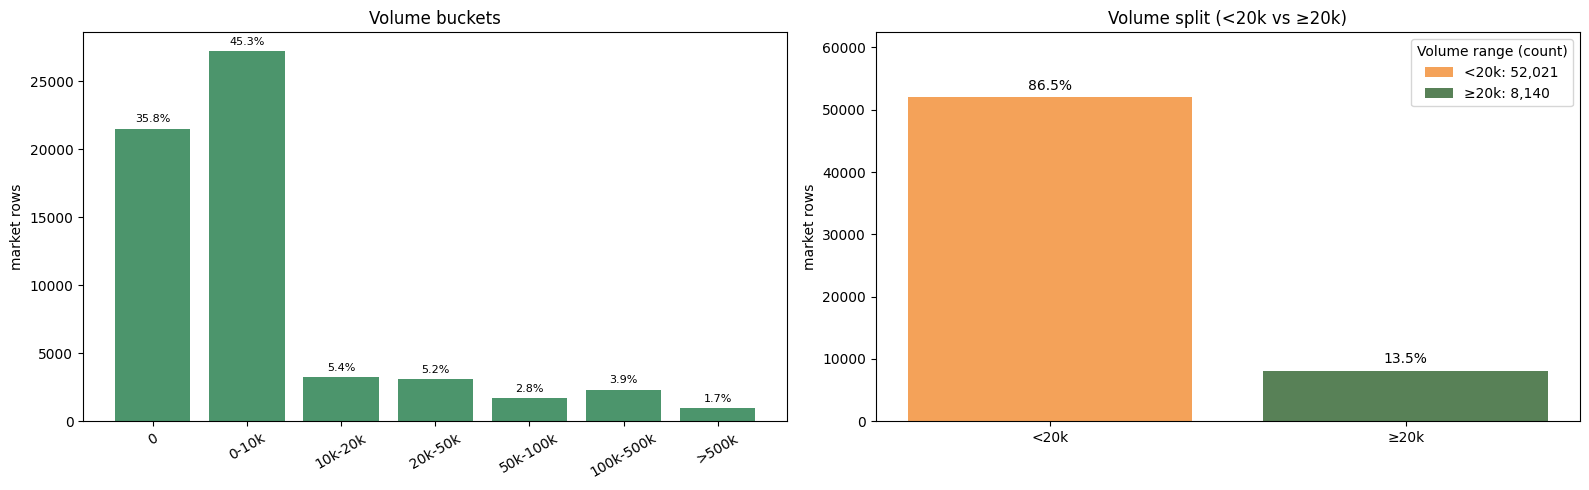

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# First plot: all detailed buckets
bars = axes[0].bar(volume_buckets["bucket"], volume_buckets["rows"], color="#4c956c")
axes[0].set_title("Volume buckets")
axes[0].set_ylabel("market rows")
axes[0].tick_params(axis="x", rotation=30)

for bar, pct in zip(bars, volume_buckets["pct_rows"]):
    height = bar.get_height()
    axes[0].annotate(
        f"{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# Second plot: just two bars, <20k and >=20k
lt_20k = ((volume >= 0) & (volume < 20000)).sum()
gte_20k = (volume >= 20000).sum()
tot = lt_20k + gte_20k
simple_buckets = ["<20k", "≥20k"]
simple_counts = [lt_20k, gte_20k]
simple_pcts = [100.0 * n / tot if tot > 0 else 0 for n in simple_counts]

bars2 = axes[1].bar(simple_buckets, simple_counts, color=["#f4a259", "#588157"])
for bar, pct, count, label in zip(bars2, simple_pcts, simple_counts, simple_buckets):
    height = bar.get_height()
    axes[1].annotate(
        f"{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )
# Add legend with counts
legend_labels = [f"{bucket}: {count:,}" for bucket, count in zip(simple_buckets, simple_counts)]
axes[1].legend(bars2, legend_labels, title="Volume range (count)", loc="upper right")

axes[1].set_title("Volume split (<20k vs ≥20k)")
axes[1].set_ylabel("market rows")
axes[1].set_ylim(0, max(simple_counts) * 1.2)
axes[1].tick_params(axis="x", rotation=0)

save_plot("kalshi_raw_markets_volume_buckets.png")
plt.show()


In [11]:
close_year_counts = (
    raw_markets.assign(close_year=pd.to_datetime(raw_markets["close_time"], utc=True, errors="coerce").dt.year.astype("Int64").astype(str))
    .groupby("close_year", dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("close_year")
)
close_year_counts


,close_year,rows
0,2021,294
1,2022,1358
2,2023,2523
3,2024,3142
4,2025,24495
5,2026,12493
6,NaN,15856


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_markets_close_year_pie.png


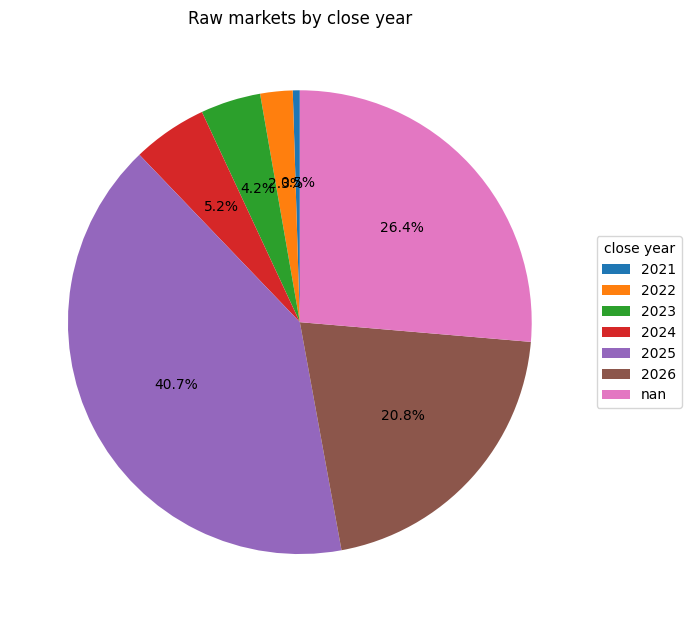

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
wedges, _, _ = ax.pie(close_year_counts["rows"], autopct="%1.1f%%", startangle=90)
ax.set_title("Raw markets by close year")
ax.legend(wedges, close_year_counts["close_year"], title="close year", loc="center left", bbox_to_anchor=(1.0, 0.5))
save_plot("kalshi_raw_markets_close_year_pie.png")
plt.show()


/var/folders/zv/mjsbg2dx4q79c1gbwtlhbk180000gp/T/ipykernel_10728/1495963063.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  raw_markets.assign(close_month=pd.to_datetime(raw_markets["close_time"], utc=True, errors="coerce").dt.to_period("M").astype(str))


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_markets_close_month_stacked.png


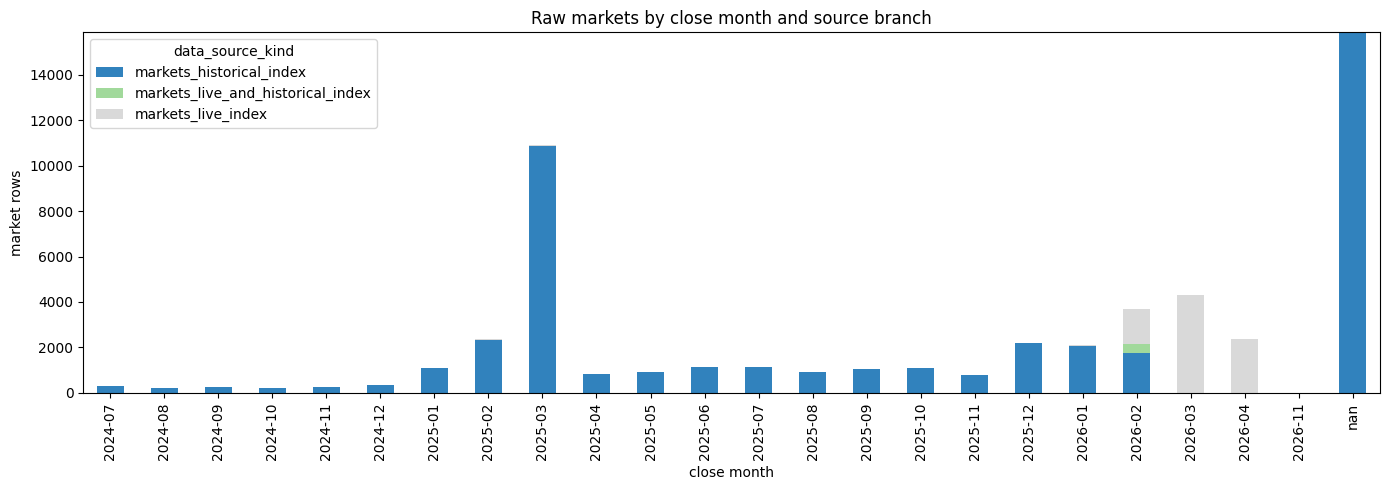

In [13]:
close_month_counts = (
    raw_markets.assign(close_month=pd.to_datetime(raw_markets["close_time"], utc=True, errors="coerce").dt.to_period("M").astype(str))
    .groupby(["close_month", "data_source_kind"], dropna=False)
    .size()
    .reset_index(name="rows")
)

close_month_pivot = (
    close_month_counts
    .pivot(index="close_month", columns="data_source_kind", values="rows")
    .fillna(0)
    .sort_index()
)

close_month_pivot.tail(24).plot(kind="bar", stacked=True, figsize=(14, 5), colormap="tab20c")
plt.title("Raw markets by close month and source branch")
plt.xlabel("close month")
plt.ylabel("market rows")
save_plot("kalshi_raw_markets_close_month_stacked.png")
plt.show()


In [14]:
is_binary = raw_markets["market_type"].fillna("").str.strip().str.lower().eq("binary")
has_volume_20k = volume.ge(20000)
after_binary = is_binary
after_volume = after_binary & has_volume_20k

filter_steps = pd.DataFrame(
    {
        "step": [
            "all raw_markets",
            "after market_type == binary",
            "after volume_num >= 20000",
        ],
        "rows": [
            len(raw_markets),
            int(after_binary.sum()),
            int(after_volume.sum()),
        ],
    }
)
filter_steps["pct_of_all"] = (100.0 * filter_steps["rows"] / max(len(raw_markets), 1)).round(2)
filter_steps["dropped_this_step"] = filter_steps["rows"].shift(1, fill_value=filter_steps.loc[0, "rows"]) - filter_steps["rows"]
filter_steps


,step,rows,pct_of_all,dropped_this_step
0,all raw_markets,60161,100.00,0
1,after market_type == binary,60161,100.00,0
2,after volume_num >= 20000,8140,13.53,52021


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_market_selection_funnel.png


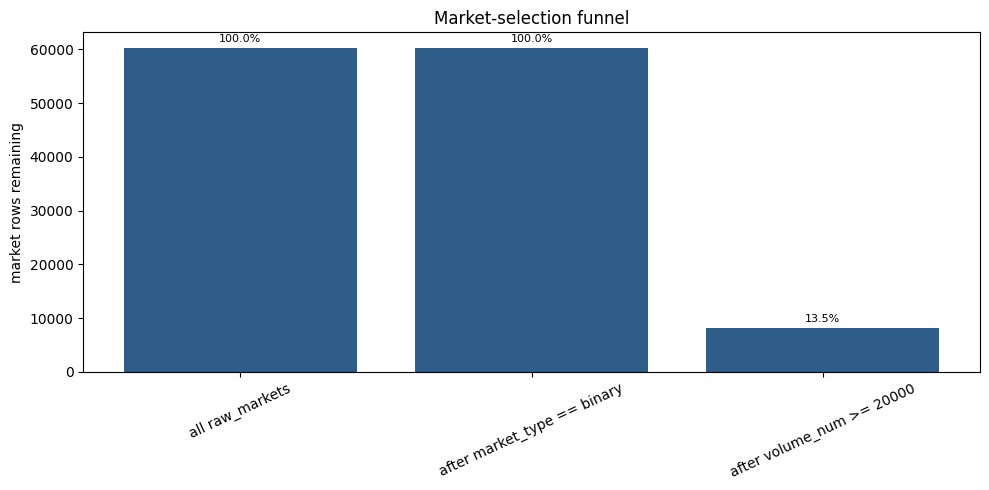

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(filter_steps["step"], filter_steps["rows"], color="#2f5d8a")
ax.set_title("Market-selection funnel")
ax.set_ylabel("market rows remaining")
ax.tick_params(axis="x", rotation=25)

for bar, pct in zip(bars, filter_steps["pct_of_all"]):
    height = bar.get_height()
    ax.annotate(
        f"{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_market_selection_funnel.png")
plt.show()


## Sample questions dropped at each market-selection stage

This cell samples markets removed by the sequential first-version market filter.


In [16]:
candidate_markets = raw_markets.loc[after_volume].copy()
candidate_volume = candidate_markets["volume_num"].fillna(0)

market_drop_samples = {
    "dropped_by_non_binary": raw_markets.loc[
        ~is_binary,
        ["market_id", "ticker", "title", "market_type", "volume_num", "data_source_kind"],
    ].sample(n=min(10, int((~is_binary).sum())), random_state=7) if int((~is_binary).sum()) else pd.DataFrame(),
    "dropped_by_volume_threshold": raw_markets.loc[
        after_binary & ~has_volume_20k,
        ["market_id", "ticker", "title", "market_type", "volume_num", "data_source_kind"],
    ].sample(n=min(10, int((after_binary & ~has_volume_20k).sum())), random_state=7) if int((after_binary & ~has_volume_20k).sum()) else pd.DataFrame(),
}

for stage_name, sample_df in market_drop_samples.items():
    print(f"\n=== {stage_name} ===")
    display(sample_df)



=== dropped_by_non_binary ===


""



=== dropped_by_volume_threshold ===


,market_id,ticker,title,market_type,volume_num,data_source_kind
25709,kalshi:KXGRAMMYWINNERS-67(AOTY)(ROTY)(SOTY)-(HMHAS)(THE)(THE),KXGRAMMYWINNERS-67(AOTY)(ROTY)(SOTY)-(HMHAS)(THE)(THE),"Will Hit Me Hard and Soft,Texas Hold 'Em,Texas Hold 'Em win Album of the Year,Record of the Year,Song of the Year at the Grammys?",binary,0.0,markets_historical_index
29125,kalshi:KXMISSUSA-25-MON,KXMISSUSA-25-MON,Miss USA Winner?,binary,0.0,markets_historical_index
48801,kalshi:KXSPOTIFYARTISTW-25AUG21-MOR,KXSPOTIFYARTISTW-25AUG21-MOR,"Top Artist on Weekly Top Artists USA on Aug 21, 2025?",binary,26.0,markets_historical_index
46784,kalshi:KXSAGAWARDACTR-26-CYN,KXSAGAWARDACTR-26-CYN,2026 Actor Award for Outstanding Performance by a Female Actor in a Leading Role?,binary,216.0,markets_historical_index
26625,kalshi:KXHOUSEMINORITY-KC,KXHOUSEMINORITY-KC,Will Katharine Clark be House Minority Leader?,binary,8.0,markets_historical_index
56617,kalshi:TSAW-23JUN25-A1.90,TSAW-23JUN25-A1.90,Will more than 1900000 people be **screened by the TSA** on average this week?,binary,0.0,markets_historical_index
26744,kalshi:KXINXMAXY-26-6199.99,KXINXMAXY-26-6199.99,"Will the maximum SP500 value reach 6199.99 by Jan 1, 2026?",binary,6944.0,markets_historical_index
30352,kalshi:KXNETFLIXRANKMOVIE-25MAY26-BAD,KXNETFLIXRANKMOVIE-25MAY26-BAD,"Top Netflix movie on May 26, 2025?",binary,0.0,markets_historical_index
12601,kalshi:KXBILLBOARDRUNNERUPSONG-25OCT25-GOL,KXBILLBOARDRUNNERUPSONG-25OCT25-GOL,"Billboard 100 #2 on Oct 25, 2025 chart?",binary,18761.0,markets_historical_index
3281,kalshi:KXILPRIMARY-07R26-CKOP,KXILPRIMARY-07R26-CKOP,Will Chad Koppie be the Republican nominee for IL-07?,binary,4012.0,markets_live_index


## Volume buckets before and after market filter

Here `after filter` means the sequential rule `market_type == binary` followed by `volume_num >= 20000`.


In [22]:
candidate_volume_buckets = pd.DataFrame(
    {
        "bucket": [
            "0",
            "0-10k",
            "10k-20k",
            "20k-50k",
            "50k-100k",
            "100k-500k",
            ">500k",
        ],
        "after_filter_rows": [
            candidate_volume.le(0).sum(),
            ((candidate_volume > 0) & (candidate_volume < 10000)).sum(),
            ((candidate_volume >= 10000) & (candidate_volume < 20000)).sum(),
            ((candidate_volume >= 20000) & (candidate_volume < 50000)).sum(),
            ((candidate_volume >= 50000) & (candidate_volume < 100000)).sum(),
            ((candidate_volume >= 100000) & (candidate_volume < 500000)).sum(),
            candidate_volume.ge(500000).sum(),
        ],
    }
)

volume_compare = volume_buckets.merge(candidate_volume_buckets, on="bucket", how="left").fillna(0)
volume_compare["after_filter_rows"] = volume_compare["after_filter_rows"].astype(int)
volume_compare


,bucket,rows,pct_rows,after_filter_rows
0,0,37986,40.47,0
1,0-10k,40657,43.32,0
2,10k-20k,4488,4.78,0
3,20k-50k,4927,5.25,4927
4,50k-100k,2320,2.47,2320
5,100k-500k,2483,2.65,2483
6,>500k,996,1.06,996


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_volume_buckets_before_after_filter.png


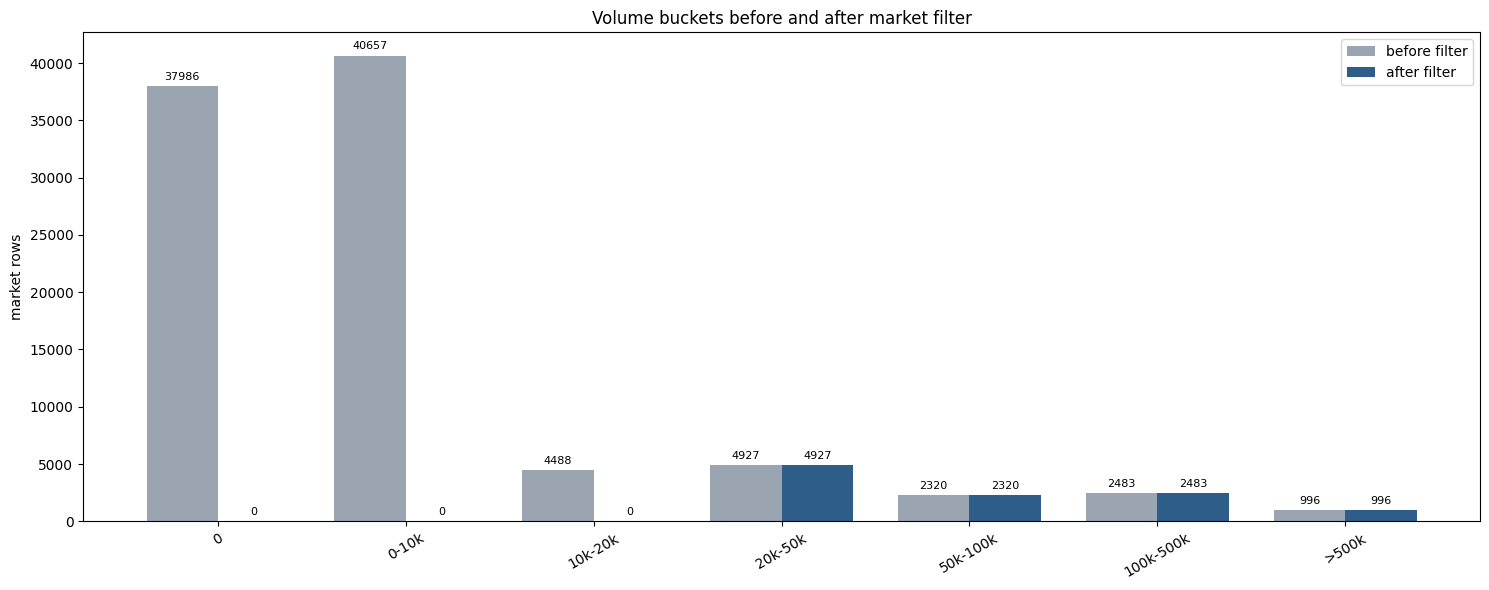

In [23]:
x = np.arange(len(volume_compare))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
bars1 = ax.bar(x - width / 2, volume_compare["rows"], width, label="before filter", color="#9aa5b1")
bars2 = ax.bar(x + width / 2, volume_compare["after_filter_rows"], width, label="after filter", color="#2f5d8a")
ax.set_title("Volume buckets before and after market filter")
ax.set_ylabel("market rows")
ax.set_xticks(x)
ax.set_xticklabels(volume_compare["bucket"], rotation=30)
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        height = int(bar.get_height())
        ax.annotate(
            f"{height}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

save_plot("kalshi_volume_buckets_before_after_filter.png")
plt.show()


In [24]:
print(candidate_markets.shape)
candidate_markets[[
    "market_id",
    "ticker",
    "event_ticker",
    "title",
    "market_type",
    "status",
    "volume_num",
    "liquidity_dollars",
    "data_source_kind",
]].sort_values("volume_num", ascending=False).head(30)


(10726, 63)


,market_id,ticker,event_ticker,title,market_type,status,volume_num,liquidity_dollars,data_source_kind
93617,kalshi:PRES-2024-KH,PRES-2024-KH,PRES-2024,Will Kamala Harris or another Democrat win the Presidency?,binary,finalized,273312857.0,0.0,markets_historical_index
93615,kalshi:PRES-2024-DJT,PRES-2024-DJT,PRES-2024,Will Donald Trump or another Republican win the Presidency?,binary,finalized,262334207.0,0.0,markets_historical_index
3135,kalshi:KXFEDCHAIRNOM-29-JS,KXFEDCHAIRNOM-29-JS,KXFEDCHAIRNOM-29,Will Trump next nominate Judy Shelton as Fed Chair?,binary,finalized,115359676.0,0.0,markets_live_index
32715,kalshi:KXGOVSHUT-26JAN31,KXGOVSHUT-26JAN31,KXGOVSHUT-26JAN31,Will the government be shut down on January 31?,binary,finalized,60576426.0,0.0,markets_historical_index
56182,kalshi:KXMAYORNYCPARTY-25-AC,KXMAYORNYCPARTY-25-AC,KXMAYORNYCPARTY-25,Will a representative of the Andrew Cuomo party win the NYC Mayor race in 2025?,binary,finalized,53423150.0,0.0,markets_historical_index
56183,kalshi:KXMAYORNYCPARTY-25-D,KXMAYORNYCPARTY-25-D,KXMAYORNYCPARTY-25,Will a representative of the Democratic party win the NYC Mayor race in 2025?,binary,finalized,48713982.0,0.0,markets_historical_index
93410,kalshi:POPVOTE-24-D,POPVOTE-24-D,POPVOTE-24,Will the Democratic party win the popular vote?,binary,finalized,45192568.0,0.0,markets_historical_index
29050,kalshi:KXFEDDECISION-25SEP-H0,KXFEDDECISION-25SEP-H0,KXFEDDECISION-25SEP,Will the Federal Reserve Hike rates by 0bps at their September 2025 meeting?,binary,finalized,42718863.0,0.0,markets_historical_index
3138,kalshi:KXFEDCHAIRNOM-29-KW,KXFEDCHAIRNOM-29-KW,KXFEDCHAIRNOM-29,Will Trump next nominate Kevin Warsh as Fed Chair?,binary,finalized,38983491.0,0.0,markets_live_index
93411,kalshi:POPVOTE-24-R,POPVOTE-24-R,POPVOTE-24,Will the Republican party win the popular vote?,binary,finalized,36740947.0,0.0,markets_historical_index


In [25]:
candidate_markets[["status", "data_source_kind"]].value_counts().rename("rows").reset_index().sort_values("rows", ascending=False).head(20)


,status,data_source_kind,rows
0,finalized,markets_historical_index,8616
1,finalized,markets_live_index,1975
2,finalized,markets_live_and_historical_index,135
